In [66]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import BayesianRidge
import matplotlib.pyplot as plt
import xgboost as xg
import pickle

In [4]:
with open("x_train_norm.npy", "rb") as file:
    x_train_norm = np.load(file)

with open("x_test_norm.npy", "rb") as file:
    x_test_norm = np.load(file)

with open("y_train.npy", "rb") as file:
    y_train = np.load(file)

with open("y_test.npy", "rb") as file:
    y_test = np.load(file)

## XGB Boost Regressor

In [28]:
xg_model = xg.XGBRFRegressor()

In [29]:
xg_model.fit(x_train_norm, y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, reg_alpha=None, ...)

In [45]:
xg_score_test = xg_model.score(x_test_norm, y_test)
print(xg_score_test)

0.8872164086468959


In [46]:
xg_score_train = xg_model.score(x_train_norm, y_train)
print(xg_score_train)

0.895770479907043


## Linear Regression

In [32]:
linear_model = LinearRegression()

In [33]:
linear_model.fit(x_train_norm, y_train)

LinearRegression()

In [47]:
linear_score_test = linear_model.score(x_test_norm, y_test)
print(linear_score_test)

0.9145225845926784


In [48]:
linear_score_train = linear_model.score(x_train_norm, y_train)
print(linear_score_train)

0.9170025567483858


## Bayesian Linear Regression

In [36]:
bayesian_model = BayesianRidge()

In [37]:
bayesian_model.fit(x_train_norm, y_train)

BayesianRidge()

In [49]:
bayesian_score_test = bayesian_model.score(x_test_norm, y_test)
print(bayesian_score_test)

0.914523694521423


In [50]:
bayesian_score_train = bayesian_model.score(x_train_norm, y_train)
print(bayesian_score_train)

0.9170025442890573


## RandomForestRegressor

In [40]:
random_forest_model = RandomForestRegressor()

In [41]:
random_forest_model.fit(x_train_norm, y_train)

RandomForestRegressor()

In [51]:
forest_score_test = random_forest_model.score(x_test_norm, y_test)
print(forest_score_test)

0.9766034193383824


In [52]:
forest_score_train = random_forest_model.score(x_train_norm, y_train)
print(forest_score_train)

0.9964477892325924


## Visualizing scores

<BarContainer object of 4 artists>

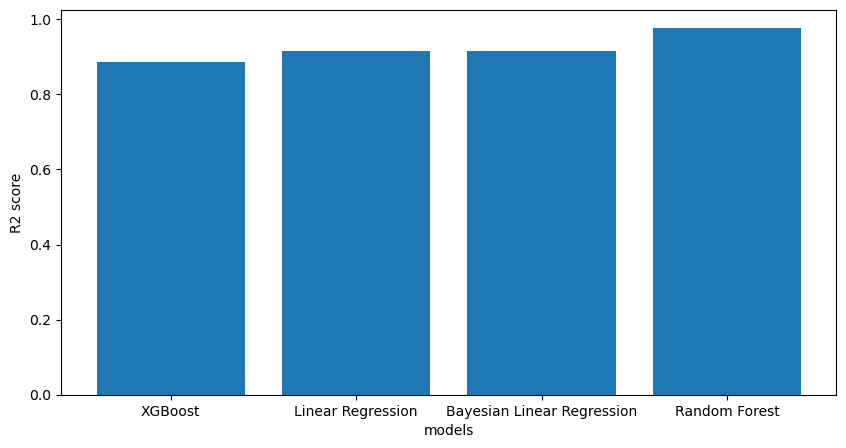

In [58]:
models = ["XGBoost", "Linear Regression", "Bayesian Linear Regression", "Random Forest"]
plt.figure(figsize=(10, 5))
plt.xlabel("models")
plt.ylabel("R2 score")
plt.bar(models, [xg_score_test, linear_score_test, bayesian_score_test, forest_score_test])

In [67]:
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(random_forest_model, file)